# PJME Hourly Load Forecasting: Hybrid Prophet‑XGBoost Model

### 🧭 Overview  
In this notebook, we build a hybrid forecasting model by combining the strengths of Prophet and XGBoost.  
Prophet captures the broader trends, seasonality, and holiday effects, while XGBoost models the remaining short-term variations and feature interactions—giving us a more accurate overall forecast.

---

### 📊 Purpose  
Implement a two‑stage forecasting pipeline:  
- **Prophet** models long‑term structure (trend, seasonalities, holidays)  
- **XGBoost** learns the residual errors and captures finer, short‑term fluctuations  

This hybrid approach aims to improve accuracy over standalone Prophet, particularly at higher frequency resolutions.

---

## 📑 Table of Contents

1. [Setup & Imports](#setup--imports)  
2. [Data Loading & Processing](#data-loading--processing)  
3. [Feature Engineering](#feature-engineering)  
4. [Evaluation Window Utilities](#evaluation-window-utilities)  
5. [Model Training & Evaluation](#model-training--evaluation)  
6. [Summary & Next Steps](#summary--next-steps)


**Notes:**  
1. adding monthly feature to prophet model (horizon= 2y) gave negligible difference.

2. It seems that forecasting a horizon of 3 years is definately bad.
    - model is unlikely to capture newer trends, and may be stuck to older ones.
    - Seasonal/Trend Shifts Over Long Horizons

---




## 1️⃣ Setup & Imports <a id="setup--imports"></a>  

In [ ]:
# Core and data processing
import os
import json
import pickle
import joblib
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import kaleido

# Forecasting and modeling
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import xgboost as xgb
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna
import holidays

# Project utilities
from utils.data_utils import *
from utils.model_utils import *

warnings.filterwarnings("ignore")



## 2️⃣ Data Loading & Processing <a id="data-loading--processing"></a>  



In [ ]:
# load df 
output_dir = 'output_hybrid_v3'

df = load_data('data/PJME_hourly.csv')

# train_set, test_set = split_train_test(df, '2017-01-01') #cut-off date 

### ⏱ Ensuring Chronological Order & Detecting Gaps

**Purpose:** As a precaution against any misalignment in later helper functions, we first sort the data in ascending order by timestamp (`ds`) and check for missing values.


In [5]:
# make sure ds is in ascending order
df = df.sort_values(by='ds').reset_index(drop=True)

check_missing_hours(df)

Missing timestamps: 30/145392
2002-04-07 03:00:00
2002-10-27 02:00:00
2003-04-06 03:00:00
2003-10-26 02:00:00
2004-04-04 03:00:00
2004-10-31 02:00:00
2005-04-03 03:00:00
2005-10-30 02:00:00
2006-04-02 03:00:00
2006-10-29 02:00:00
2007-03-11 03:00:00
2007-11-04 02:00:00
2008-03-09 03:00:00
2008-11-02 02:00:00
2009-03-08 03:00:00
2009-11-01 02:00:00
2010-03-14 03:00:00
2010-11-07 02:00:00
2010-12-10 00:00:00
2011-03-13 03:00:00
2011-11-06 02:00:00
2012-03-11 03:00:00
2012-11-04 02:00:00
2013-03-10 03:00:00
2013-11-03 02:00:00
2014-03-09 03:00:00
2015-03-08 03:00:00
2016-03-13 03:00:00
2017-03-12 03:00:00
2018-03-11 03:00:00


### Analysis of Missing Timestamps

The list of missing timestamps in the dataset (e.g., `2002-04-07 03:00:00`, `2002-10-27 02:00:00`, etc.) strongly suggests that these gaps are due to Daylight Saving Time (DST) transitions. Typically, during the "spring forward" transition, clocks skip from 2:00 AM to 3:00 AM, resulting in the absence of the 2:00–3:00 AM hour. Conversely, during the "fall back" transition, the 2:00 AM hour is repeated, which can sometimes cause duplicate or ambiguous timestamps.

The pattern and timing of the missing hours align with the expected DST changes in the United States, indicating that the dataset is missing hours due to these time adjustments rather than random data loss.



In [7]:
# Set 'ds' as index for time-based operations
df = df.set_index('ds')

# Print the number of duplicate timestamps
print("Number of duplicates:", df.index.duplicated().sum())

# Print all rows that are duplicates (excluding the first occurrence)
print("Duplicate rows:")
print(df[df.index.duplicated(keep=False)])

Number of duplicates: 4
Duplicate rows:
                           y
ds                          
2014-11-02 02:00:00  23755.0
2014-11-02 02:00:00  22935.0
2015-11-01 02:00:00  21567.0
2015-11-01 02:00:00  21171.0
2016-11-06 02:00:00  20795.0
2016-11-06 02:00:00  21692.0
2017-11-05 02:00:00  21236.0
2017-11-05 02:00:00  20666.0


### Handling Duplicate Timestamps and DST-Related Gaps

During Daylight Saving Time transitions, two issues occur:

1. **“Fall-back” duplicates**  
   In autumn, clocks move back one hour. For example, on `2014-11-02`, two different load readings share the timestamp `02:00:00`. Leaving both rows creates ambiguity for lagged features, since “one hour ago” could refer to either reading.

2. **“Spring-forward” gaps**  
   In spring, clocks skip ahead one hour. For example, `2002-04-07 03:00:00` is missing. Any operation that assumes a continuous hourly index (e.g. `.shift(1)` or `.rolling(24)`) fails at these gaps.

---

### Resolving Duplicate Timestamps

- **Cause:** Two readings for the same nominal hour occur when the clock is set back.  
- **Solution:** Aggregate duplicates by taking their mean. This preserves information from both readings rather than dropping one arbitrarily.


In [8]:
# simple linear (time) interpolation 

# Identify and aggregate duplicates by taking the mean of 'y'
df = df.groupby(level=0).mean()

# Create complete hourly index
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')

# Reindex to include all timestamps
df = df.reindex(full_range)

# Interpolate and fill
df['y'] = df['y'].interpolate(method='time')
df['y'] = df['y'].ffill().bfill()

df = df.reset_index().rename(columns={'index': 'ds'})
df['ds'] = pd.to_datetime(df['ds'])  # Ensure it's datetime
check_missing_hours(df)

Missing timestamps: 0/145392


## 3️⃣ Feature Engineering <a id="feature-engineering"></a>

**Notes:**  
- **Lag** and **rolling** features are **excluded** from this notebook as they introduce an unrealistic advantage in long-horizon forecasting. 

- For example, a 24-hour lag or a rolling mean over recent hours may strongly reflect short-term trends — which can be helpful in near-term prediction, but misleading when the horizon is weeks or even months ahead.  

- In such cases, the model would effectively rely on recent patterns that wouldn't be available or meaningful at the time of prediction.  
To avoid this mismatch between training conditions and real-world use, we drop lag- and rolling-based features in favor of purely time-aware signals (e.g. hour, day of week, holiday).

- Including a monthly feature in the Prophet model (for a 2-year forecast horizon) resulted in negligible improvement in performance.

In [ ]:
def create_features_xgboost(df):
    """
    Create temporal and cyclical features from the datetime column.

    Args:
        df (pd.DataFrame): DataFrame with 'ds' (datetime) and 'y' (target) columns.
    Returns:
        pd.DataFrame: DataFrame with added features.

    Note:
        Introducing information up to yₜ₋₁, such as from 'lag' and 'rolling' features, 
        essentially turns the task into a short-term or step-ahead forecast, 
        rather than a more "honest" long-horizon prediction.

        This function also one-hot encodes the 'quarter' and 'season' categorical features.
    """
    # Temporal features
    df['hour'] = df['ds'].dt.hour
    df['day_of_week'] = df['ds'].dt.dayofweek
    df['day_of_month'] = df['ds'].dt.day
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

    # Quarterly (annual) features
    quarters = {
        1: 'Q1_Jan-Mar',
        2: 'Q2_Apr-Jun',
        3: 'Q3_Jul-Sep',
        4: 'Q4_Oct-Dec'
    }
    df['quarter'] = df['ds'].dt.quarter.map(quarters)

    # Rough Seasons 
    def month_to_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Autumn'
    df['season'] = df['ds'].dt.month.map(month_to_season)
    
    # Cyclical hour encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


    # Adding holidays
    years = df['ds'].dt.year.unique()
    us_holidays = holidays.US(years=years)
    holiday_dates = list(us_holidays.keys())
    index_dates = df['ds'].dt.date
    df["is_holiday"] = index_dates.isin(holiday_dates).astype(int)
    
    #One hot encode
    df = pd.get_dummies(df, columns=['quarter', 'season'])

    return df

In [ ]:
df = create_features_xgboost(df)

df.head()

,ds,y,hour,day_of_week,day_of_month,is_weekend,hour_sin,hour_cos,is_holiday,quarter_Q1_Jan-Mar,quarter_Q2_Apr-Jun,quarter_Q3_Jul-Sep,quarter_Q4_Oct-Dec,season_Autumn,season_Spring,season_Summer,season_Winter
0,2002-01-01 01:00:00,30393.0,1,1,1,0,0.258819,0.965926,1,True,False,False,False,False,False,False,True
1,2002-01-01 02:00:00,29265.0,2,1,1,0,0.500000,0.866025,1,True,False,False,False,False,False,False,True
2,2002-01-01 03:00:00,28357.0,3,1,1,0,0.707107,0.707107,1,True,False,False,False,False,False,False,True
3,2002-01-01 04:00:00,27899.0,4,1,1,0,0.866025,0.500000,1,True,False,False,False,False,False,False,True
4,2002-01-01 05:00:00,28057.0,5,1,1,0,0.965926,0.258819,1,True,False,False,False,False,False,False,True


## 4️⃣ Evaluation Window Utilities <a id="evaluation-window-utilities"></a>  
**Purposes:** 
- Define helper functions to split the test set into calendar-aligned and rolling monthly windows.  

- These windows are used later to analyze how the hybrid model performs over time, both month-by-month and cumulatively.


In [ ]:
from pandas.tseries.offsets import MonthEnd

def split_test_set_by_month(test_set):
    """
    Splits the test_set DataFrame into a list of DataFrames, each containing one month of data.

    Args:
        test_set (pd.DataFrame): DataFrame with a 'ds' datetime column.

    Returns:
        List[pd.DataFrame]: List of DataFrames, one per month in test_set.
    """
    
    months = test_set['ds'].dt.to_period('M').unique()
    print(f"Total splits: {len(months)}")

    monthly_splits = []
    for month in months:
        mask = test_set['ds'].dt.to_period('M') == month
        monthly_splits.append(test_set[mask])

        first = test_set[mask]['ds'].min()
        last = test_set[mask]['ds'].max()

        print(f"Month: {month}")
        print(f"{first} to {last} \n")

    return monthly_splits

def rolling_test_horizons(test_set, max_months=12):
    """
    For each horizon from 1 to max_months, returns a list of DataFrames,
    where each DataFrame contains the first N months of the test set.

    Args:
        test_set (pd.DataFrame): DataFrame with a 'ds' datetime column.
        max_months (int): Maximum number of months to include.

    Returns:
        List[pd.DataFrame]: Each DataFrame contains data from the start up to the Nth month.
    """
    start = test_set['ds'].min()
    horizons = []
    for n in range(1, max_months + 1):
        end = (start + MonthEnd(n))
        mask = (test_set['ds'] >= start) & (test_set['ds'] <= end)
        horizons.append(test_set[mask])
    return horizons

In [12]:
train_set, test_set = split_train_test(df,'2017-08-01')

print(f"train_set: {train_set['ds'].min()} to {train_set['ds'].max()}")
print(f"test_set : {test_set['ds'].min()} to {test_set['ds'].max()}")

train_set: 2002-01-01 01:00:00 to 2017-07-31 23:00:00
test_set : 2017-08-01 00:00:00 to 2018-08-03 00:00:00


### ⚠️ Dropping Partial Last Month

The last month in the test set contains only 2 days of data, which is much shorter than a typical month.  
To ensure fair and consistent evaluation, we drop this partial month from further analysis.

In [13]:
monthly_splits = split_test_set_by_month(test_set)

# Drop last partial month if it's shorter than a full month (e.g., < 28 days)
full_month_splits = [df for df in monthly_splits if len(df) >= 28 * 24]

full_month_splits[-1]['ds'].min()

Total splits: 13
Month: 2017-08
2017-08-01 00:00:00 to 2017-08-31 23:00:00 

Month: 2017-09
2017-09-01 00:00:00 to 2017-09-30 23:00:00 

Month: 2017-10
2017-10-01 00:00:00 to 2017-10-31 23:00:00 

Month: 2017-11
2017-11-01 00:00:00 to 2017-11-30 23:00:00 

Month: 2017-12
2017-12-01 00:00:00 to 2017-12-31 23:00:00 

Month: 2018-01
2018-01-01 00:00:00 to 2018-01-31 23:00:00 

Month: 2018-02
2018-02-01 00:00:00 to 2018-02-28 23:00:00 

Month: 2018-03
2018-03-01 00:00:00 to 2018-03-31 23:00:00 

Month: 2018-04
2018-04-01 00:00:00 to 2018-04-30 23:00:00 

Month: 2018-05
2018-05-01 00:00:00 to 2018-05-31 23:00:00 

Month: 2018-06
2018-06-01 00:00:00 to 2018-06-30 23:00:00 

Month: 2018-07
2018-07-01 00:00:00 to 2018-07-31 23:00:00 

Month: 2018-08
2018-08-01 00:00:00 to 2018-08-03 00:00:00 



Timestamp('2018-07-01 00:00:00')

## 5️⃣ Model Training & Hyperparameter Optimization <a id="model-training--evaluation"></a>

In this section, we train the hybrid Prophet-XGBoost model and use Optuna to optimize the Prophet hyperparameters.  
- **Prophet**: Fit to the cleaned training data, with hyperparameters tuned via Optuna for best forecasting performance.
- **Optuna**: Performs cross-validation to search for the best Prophet configuration, minimizing MAPE.
- **Residuals**: After Prophet fitting, residuals are computed for further modeling with XGBoost in the next steps.


**Note:**  
It seems that forecasting a horizon of 3 years is definitely bad.
- The model is unlikely to capture newer trends and may be stuck to older ones.
- Seasonal/trend shifts over long horizons.
---

### 🧮 Hybrid Model Theory

The hybrid approach integrates Prophet’s long-term trend modeling with XGBoost’s ability to capture short-term, non-linear residual patterns.

We define:

- **Prophet prediction:**

  $$
  \hat{y}_p
  $$

- **Residuals (what Prophet misses):**

  $$
  r = y - \hat{y}_p
  $$

- **Hybrid forecast:**

  $$
  \hat{y}_{\text{Hybrid}} = \hat{y}_p + r
  $$

If the residuals are perfectly predicted by XGBoost (i.e. $( \hat{r}_{\text{XGB}} = r ))$, then:

$$
\hat{y}_{\text{Hybrid}} = \hat{y}_p + (y - \hat{y}_p) = y
$$

So in the ideal case, the hybrid model exactly recovers the true value.

---

### 💡 Why Hybrid Models Work Better

Prophet is excellent at modeling **global patterns** like trends, seasonality, and holidays in a highly interpretable way. However, it often struggles with **local fluctuations**, noise, and non-linear interactions in the data.

XGBoost, on the other hand, is a powerful machine learning algorithm that can capture:

- Sudden changes or spikes,
- Interactions between features,
- Non-periodic local variation.

By combining both:

- Prophet handles the **macro-structure** of the signal,
- XGBoost learns the **micro-level corrections**.

This complementary setup allows the hybrid model to adapt to a wider range of behaviors in the data.

---

### 📉 Error Comparison: Why Hybrid Improves Accuracy

Let the error metrics be defined as:

- **Prophet error:**  
  $$
  \varepsilon_p = |y - \hat{y}_p| = |r|
  $$

- **Hybrid error:**  
  $$
  \varepsilon_h = |y - \hat{y}_{\text{Hybrid}}| = |r - \hat{r}_{\text{XGB}}|
  $$

#### 1. 🔍 Residual Learning Intuition

The hybrid model directly targets Prophet's prediction error by modeling the residuals \( r \).  
Even a partial correction of the residual leads to lower overall error:

$$
\varepsilon_h = |r - \hat{r}_{\text{XGB}}| < |r| = \varepsilon_p
$$

This holds as long as \( \hat{r}_{\text{XGB}} \) captures meaningful structure in the residuals and is not just noise.


#### 2. 📐 Triangle Inequality Insight

By the triangle inequality:

$$
\varepsilon_h = |r - \hat{r}_{\text{XGB}}| \leq |r| + |\hat{r}_{\text{XGB}}|
$$

But more importantly, when \( \hat{r}_{\text{XGB}} \) approximates \( r \), the hybrid error can significantly shrink.

Suppose:

$$
\hat{r}_{\text{XGB}} = \alpha r \quad \text{for some } 0 < \alpha < 1
$$

Then:

$$
\varepsilon_h = |r - \alpha r| = |(1 - \alpha)r| = (1 - \alpha)|r|
$$

So:

$$
\varepsilon_h < \varepsilon_p
$$

---

#### ✅ Summary

Even if XGBoost doesn't perfectly learn the residuals, **any predictive signal** it captures reduces the total forecast error.  
This makes the hybrid model **consistently more accurate** than Prophet alone under realistic conditions.

---



### 🔄 Retraining Prophet model

**Note:**
- *Due to working from a different machine without access to previous outputs, the Prophet model was retrained in this notebook.*

- *This ensures all results and artifacts are reproducible and available for the subsequent hybrid modeling steps.*


In [ ]:
# #Optuna study
# results = {}

# def objective(trial):
#     """
#     Objective function to optimize Prophet model hyperparameters along with the cleaning parameters.

#     Uses cross-validation with specified settings and returns the mean MAPE.
#     """
#     # Clean the training data using hyperparameter suggestions from the trial
#     cleaned_train_set, hurricane_dates = clean_train_data(trial, train_set)
    
#     # Prophet hyperparameter suggestions from the trial
#     prophet_params = {
#         'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.05, log=True),
#         'changepoint_range': trial.suggest_float('changepoint_range', 0.3, 0.9),
#         'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
#         'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 5.0, log=True),
#         'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.5, 12),
#         'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['multiplicative', 'additive']),
#         'yearly_seasonality': trial.suggest_int('yearly_seasonality', 4, 12)
#     }
    
#     # Initialize the Prophet model using the provided parameters and hurricane dates
#     model = Prophet(
#         **prophet_params,
#         holidays=hurricane_dates,
#         daily_seasonality=False,
#         weekly_seasonality=False
#         )
#     model.add_country_holidays('US')
    
#     # Fit the model on the cleaned training data.
#     try:
#         model.fit(cleaned_train_set)
#     except Exception as e:
#         print(f"Fitting failed: {str(e)}")
#         return 100.0  # Return a high error if the fitting fails
    
#     # Perform cross-validation to evaluate the model's performance
#     try:
#         df_cv = cross_validation(
#             model,
#             initial='730 days',
#             period='180 days',
#             horizon='365 days',
#             disable_tqdm=True,
#             parallel="processes"
#         )              
#         df_p = performance_metrics(df_cv, rolling_window=1)
#         mape_cv = df_p['mape'].mean()
#     except Exception as e:
#         print(f"Validation failed: {str(e)}")
#         mape_cv = 100.0  # Penalize invalid configurations

#     forecast_train = model.predict(cleaned_train_set)
#     forecast_test = model.predict(test_set)
#     mape_train, mape_test, residuals_train, residuals_test = get_MAPE(cleaned_train_set, test_set, 
#                                                                       forecast_train, forecast_test, 
#                                                                       show=False)
    
#     # Save the results into the results dict
#     results[trial.number]  = {
#         'trial_number' : trial.number,
#         'mape_cv' : mape_cv,
#         'mape_train' : mape_train,
#         'mape_test' : mape_test,
#         'residuals_train' : residuals_train,
#         'residuals_test' : residuals_test,
#         'params' : prophet_params
#     }
    
#     return mape_cv


In [ ]:
# import time

# if __name__ == "__main__":

#     # Create an Optuna study to minimize MAPE
#     timestamp = int(time.time())
#     study_name = f"Prophet_optimization_{timestamp}"
#     storage_name = f"sqlite:///{output_dir}/{study_name}.db"

#     study = optuna.create_study(
#         direction='minimize',
#         study_name=study_name,
#         storage=storage_name,
#         sampler=optuna.samplers.TPESampler(seed=42)
#     )

#     # try:
#     #     # Try loading existing study
#     #     study = optuna.load_study(
#     #         study_name="Prophet_II_study",
#     #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db"
#     #     )
#     #     print("Resuming existing study")
#     # except KeyError:
#     #     # Create new study if doesn't exist
#     #     study = optuna.create_study(
#     #         direction='minimize',
#     #         study_name="Prophet_II_study",
#     #         storage=f"sqlite:///{output_dir}/Prophet_II_study.db",
#     #         sampler=optuna.samplers.TPESampler(seed=42)
#     #     )
#     #     print("Created new study")

#     # Optimize the objective function 
#     study.optimize(objective, n_trials=10, timeout=3600 * 6)

#     # Get best parameters
#     best_params = study.best_params
#     best_cleaning_params = {
#         'window_size': best_params['window_size'],
#         'iqr_multiplier': best_params['iqr_multiplier'],
#         'hurricane_window': best_params['hurricane_window']
#     }
#     best_prophet_params = {
#         k: best_params[k] for k in [
#             'changepoint_prior_scale',
#             'changepoint_range',
#             'n_changepoints',
#             'seasonality_prior_scale',
#             'holidays_prior_scale',
#             'seasonality_mode',
#             'yearly_seasonality'
#         ]
#     }

#     # Save parameters
#     with open(os.path.join(output_dir, 'best_cleaning_params.json'), 'w') as f:
#         json.dump(best_cleaning_params, f, indent=2)
#     with open(os.path.join(output_dir, 'best_prophet_params.json'), 'w') as f:
#         json.dump(best_prophet_params, f, indent=2)


#     # Verification and model saving
#     cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
#     final_model = Prophet(
#         **best_prophet_params,
#         holidays=hurricane_dates,
#         daily_seasonality=False,
#         weekly_seasonality=False
#     )
#     final_model.add_country_holidays('US')
#     final_model.fit(cleaned_train_set)
    
#     # Recompute CV MAPE
#     try:
#         df_cv = cross_validation(
#             final_model,
#             initial='730 days',
#             period='180 days',
#             horizon='365 days',
#             disable_tqdm=True,
#             parallel="processes"
#         )
#         df_p = performance_metrics(df_cv, rolling_window=1)
#         verified_mape = df_p['mape'].mean()
#     except Exception as e:
#         print(f"Verification failed: {str(e)}")
#         verified_mape = 100.0

#     # Compare to original
#     original_mape = study.best_value
#     print(f"\nVerification:")
#     print(f"Original best MAPE: {original_mape*100:.6f}%")
#     print(f"Recomputed MAPE:   {verified_mape*100:.6f}%")
#     print(f"Difference:        {(verified_mape - original_mape)*100:.6f}%")
    
#     # Save model if verification passes
#     if abs(verified_mape - original_mape) < 0.005:
#         model_path = os.path.join(output_dir, 'prophet_final_model.pkl')
#         joblib.dump(final_model, model_path)
#         print("Verification success!!")
#         print(f"Model saved to {model_path}")
#     else:
#         print("Verification failed! Model not saved.")
    
#     # Save study visualization
#     fig = optuna.visualization.plot_optimization_history(study)
#     fig.write_image(os.path.join(output_dir, 'optimization_history.png'))
           

#     # Save param importances visualization
#     fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
#     fig.write_image(os.path.join(output_dir, 'param_importances.png'))

#     print(f"Best trial #: {study.best_trial.number}")     
#     print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%") 
#     print("Best params:")
#     for key, value in best_params.items():
#         print(f"- {key}: {value}")


#     # Print summary
#     print(f"\nBest trial: #{study.best_trial.number}")
#     print(f"Best params:")
#     for k, v in best_params.items():
#         print(f"- {k}: {v}")

[I 2025-06-07 00:30:23,527] A new study created in RDB with name: Prophet_optimization_1749249021
00:30:48 - cmdstanpy - INFO - Chain [1] start processing
00:31:11 - cmdstanpy - INFO - Chain [1] done processing
00:31:15 - cmdstanpy - INFO - Chain [1] start processing
00:31:16 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:17 - cmdstanpy - INFO - Chain [1] start processing
00:31:18 - cmdstanpy - INFO - Chain [1] start processing
00:31:19 - cmdstanpy - INFO - Chain [1] start processing
00:31:19 - cmdstanpy - INFO - Chain [1] start processing
00:31:20 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - INFO - Chain [1] done processing
00:31:30 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 11 Unknown error -11
Optimization terminated abnormally. Falling back to Newton.
00:31:31 - cmds


Verification:
Original best MAPE: 14.080491%
Recomputed MAPE:   14.080491%
Difference:        0.000000%
Verification success!!
Model saved to output_hybrid_v2/prophet_final_model.pkl
Best trial #: 9
Best MAPE (Cross-Validation): 14.08%
Best params:
- window_size: 79
- iqr_multiplier: 2.094287557060203
- hurricane_window: 4
- changepoint_prior_scale: 0.003420435321164825
- changepoint_range: 0.6051424146988217
- n_changepoints: 47
- seasonality_prior_scale: 0.04707954411452836
- holidays_prior_scale: 5.219403614909742
- seasonality_mode: multiplicative
- yearly_seasonality: 4

Best trial: #9
Best params:
- window_size: 79
- iqr_multiplier: 2.094287557060203
- hurricane_window: 4
- changepoint_prior_scale: 0.003420435321164825
- changepoint_range: 0.6051424146988217
- n_changepoints: 47
- seasonality_prior_scale: 0.04707954411452836
- holidays_prior_scale: 5.219403614909742
- seasonality_mode: multiplicative
- yearly_seasonality: 4


### 5.2 🚀 XGBoost Pipeline Setup & Optimization

*Prepare features and residuals, then use Optuna to tune XGBoost. Train the final model and combine with Prophet for hybrid forecasts.*

---

#### 📦 Load Best Parameters

Before training the hybrid model, we load the optimal data cleaning and Prophet hyperparameters found during previous Optuna optimization runs.  
These parameters ensure that both the data preprocessing and Prophet model are consistent with the best-performing configuration from earlier experiments.

- **Cleaning parameters:** Control outlier removal, hurricane windowing, and other preprocessing steps.
- **Prophet parameters:** Define the model’s flexibility and seasonal structure.


In [ ]:
input_dir = "output_hybrid_v2"  

# Load cleaning parameters
with open(os.path.join(input_dir, 'best_cleaning_params.json'), 'r') as f:
    best_cleaning_params = json.load(f)

# Load Prophet parameters
with open(os.path.join(input_dir, 'best_prophet_params.json'), 'r') as f:
    best_prophet_params = json.load(f)

### 🚀 XGBoost Model Pipeline Setup & Optuna Hyperparameter Optimization

This section defines the **Optuna objective function** for the XGBoost regression pipeline in the hybrid forecasting model.  
Optuna is used to efficiently search for the best XGBoost hyperparameters.

---

#### 🧪 Optimization Workflow

- **Hyperparameter Search:**  
  Defines the search space for XGBoost hyperparameters (e.g., `n_estimators`, `learning_rate`, `max_depth`, etc.).

- **Time Series Cross-Validation:**  
  Uses `TimeSeriesSplit` to ensure each validation fold follows its corresponding training fold chronologically, preserving temporal integrity.

- **Hybrid Forecasting Strategy:**  
  - For each fold, XGBoost is trained on Prophet residuals from the training split.
  - Residuals are predicted on the validation split.
  - The final hybrid forecast is computed as Prophet forecast plus XGBoost-predicted residuals.
  - Forecast accuracy is measured using Mean Absolute Percentage Error (MAPE).

- **Optuna Objective:**  
  Returns the average MAPE across all folds for Optuna to minimize.


In [ ]:

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'tree_method': 'hist',  
        'objective': 'reg:squarederror',
        'random_state': 42
    }


    # TimeSeriesSplit for cross-validation
    tscv = TimeSeriesSplit(n_splits=6)
    mape_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        # Split the data into training and validation sets
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = residuals_train.iloc[train_idx], residuals_train.iloc[val_idx]

        # Train the XGBoost model
        xgb_model = xgb.XGBRegressor(**params)  
        xgb_model.fit(X_train_fold, y_train_fold)

        # Predict on the validation set
        residual_pred_val = xgb_model.predict(X_val_fold)

        # Combine Prophet and XGBoost predictions
        final_forecast_val = forecast_train['yhat'].iloc[val_idx].values + residual_pred_val

        # Calculate MAPE for the validation set
        actual_val = cleaned_train_set['y'].iloc[val_idx].values
        mape = mean_absolute_percentage_error(actual_val, final_forecast_val)
        mape_scores.append(mape)

    # Return the average MAPE across all folds
    return np.mean(mape_scores)

### 🛠️ Data Preparation & Checks for Hybrid Model

This cell prepares all data and performs key checks before running Optuna for XGBoost hyperparameter optimization in the hybrid Prophet-XGBoost pipeline.

**Workflow:**
- **Clean Training Data:** Apply best cleaning parameters to the training set and print shape.
- **Load Prophet Model:** Load the optimized Prophet model and confirm with a print.
- **Generate Forecasts:** Get Prophet predictions for train and test sets; print sample outputs.
- **Compute Residuals:** Calculate the difference between actuals and Prophet predictions; print summary statistics.
- **Prepare Features:** Drop `ds` and `y` to create XGBoost feature matrices; align test features with train columns; print feature shapes.
- **Integrity Checks:**  
  - Ensure feature and residual row counts match (print check result).
  - Confirm index alignment between features and residuals (print check result).
  - Verify timestamp consistency between cleaned data and Prophet forecasts (print check result).
- **Save Artifacts:**  
  - Best XGBoost hyperparameters (`best_xgboost_params_*.json`)
  - Optuna study results (`xgboost_study_results_*.pkl`)
  - Final trained hybrid model (`hybrid_model_*.pkl`)
  - Visualizations (optimization history, parameter importances, feature importances)
  - Monthly and rolling evaluation results (`monthly_results_*.json`, `rolling_results_*.json`)


In [ ]:
import time

output_dir = 'output_hybrid_v3'

if __name__ == "__main__":

    # Clean train set
    cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)

    # Load prophet model
    model_path = os.path.join(input_dir, 'prophet_final_model.pkl') 
    prophet_model = joblib.load(model_path)

    # Prophet Forecast
    forecast_train = prophet_model.predict(cleaned_train_set)
    forecast_test = prophet_model.predict(test_set[['ds']])

    # Compute residuals
    residuals_train = cleaned_train_set['y'] - forecast_train['yhat']
    residuals_test = test_set['y'] - forecast_test['yhat'] 

    # Drop NaNs and align indices
    valid_idx = residuals_train.dropna().index
    residuals_train = residuals_train.loc[valid_idx]

    # Prepare feature matrices by dropping 'ds' and 'y'
    X_train = cleaned_train_set.loc[valid_idx].drop(columns=['ds', 'y'])
    X_test = test_set.drop(columns=['ds', 'y'])

    # Align test columns with training columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


    # Final checks
    # 1) Same number of rows?
    assert X_train.shape[0] == residuals_train.shape[0], (
        f"Row count mismatch: X_train={X_train.shape[0]} vs residuals_train={residuals_train.shape[0]}"
    )

    # 2) Exact same index ordering?
    assert X_train.reset_index(drop=True).index.equals(
            residuals_train.reset_index(drop=True).index
        ), "Feature/target index misalignment"

    # 3) Cleaned vs. forecast alignment on timestamps
    assert cleaned_train_set['ds'].reset_index(drop=True).equals(
            forecast_train['ds'].reset_index(drop=True)
        ), "Mismatch in 'ds' between cleaned_train_set and forecast_train"

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"xgboost_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # Optimize the objective function 
    study.optimize(objective, n_trials=100, timeout=3600*2)

    # Get best parameters
    best_params = study.best_params

    best_xgboost_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    # Print the best parameters and MAPE
    print("-------------------------------------------------------")
    print(f"Best MAPE: {best_params}")
    print("Best Parameters:")
    for key, value in best_params.items():
        print(f"{key}: {value}")

    # Save parameters
    with open(os.path.join(output_dir, f'best_xgboost_params_{timestamp}.json'), 'w') as f:
        json.dump(best_xgboost_params, f, indent=2)

    # Save the study results
    with open(os.path.join(output_dir, f'xgboost_study_results_{timestamp}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    # # Load prophet model with the best parameters
    # cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
    # model_path = os.path.join(input_dir, 'prophet_final_model.pkl')
    # prophet_model = joblib.load(model_path)


    # Train the final XGBoost model with the best parameters
    best_params = study.best_params
    xgb_model = xgb.XGBRegressor(**best_xgboost_params)
    xgb_model.fit(X_train, residuals_train)

    # Predict residuals on the test set
    residual_pred_test = xgb_model.predict(X_test)
    hybrid_forecast_test = forecast_test['yhat'].iloc[:len(X_test)].values + residual_pred_test


    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, f'optimization_history_{timestamp}.png'))

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, f'param_importances_{timestamp}.png'))

    # Create and save features importance plot
    fig, ax = plt.subplots(figsize=(10,6))
    plot_importance(xgb_model, ax=ax, max_num_features=20)  # show top 20
    plt.tight_layout()
    output_path = os.path.join(output_dir, f'xgb_feature_importances_{timestamp}.png')
    plt.savefig(output_path)
    plt.close(fig)


    print("-------------------------------------------------------")
    print(f"Best trial #: {study.best_trial.number}")
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%")
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")
    print("-------------------------------------------------------")

    # Save the final model      
    model_path = os.path.join(output_dir, f'hybrid_model_{timestamp}.pkl')
    joblib.dump((prophet_model, xgb_model), model_path)
    print(f"Final model saved to {model_path}")
    print("-------------------------------------------------------")

    # Extract just ds + yhat from your Prophet forecast
    fc = forecast_test[['ds','yhat']].rename(columns={'yhat':'yhat_prophet'})

    print("Start evaluating models on test set")
    monthly_results = {}
    # Loop over each monthly split
    for i, month in enumerate(full_month_splits, start=1):
        print(f"Evaluating Month {i}: {month['ds'].min()} → {month['ds'].max()}")

        # Merge in the Prophet forecast
        m = month.merge(fc, on='ds', how='left')

        # Build the feature matrix for XGBoost:
        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_month = (
            m
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align m itself to the rows we kept in X_test_month
        m = m.loc[X_test_month.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_month)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = m['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(m['y'].values, m['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(m['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        monthly_results[f'month_{i}'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    print("-------------------------------------------------------")


    rolling_results = {}
   
    # Create rolling horizons from the test set
    rolling_horizons = rolling_test_horizons(test_set, max_months=12)

    # Loop over each monthly split
    for i, horizon in enumerate(rolling_horizons, start=1):
        print(f"Evaluating Horizon {i}: {horizon['ds'].min()} → {horizon['ds'].max()}")

        # Merge in the Prophet forecast
        h = horizon.merge(fc, on='ds', how='left')

        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_horizon = (
            h
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align h itself to the rows we kept in X_test_horizon
        h = h.loc[X_test_horizon.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_horizon)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = h['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(h['y'].values, h['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(h['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        rolling_results[f'{i} month(s)'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    # Save monthly and rolling results
    with open(os.path.join(output_dir, f'monthly_results_{timestamp}.json'), 'w') as f:
        json.dump(monthly_results, f, indent=2)
    with open(os.path.join(output_dir, f'rolling_results_{timestamp}.json'), 'w') as f:
        json.dump(rolling_results, f, indent=2)
        

[I 2025-06-12 23:43:15,108] A new study created in RDB with name: xgboost_optimization_1749764594
[I 2025-06-12 23:43:26,597] Trial 0 finished with value: 0.07868518596680069 and parameters: {'n_estimators': 200, 'learning_rate': 0.14285357442943783, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.07868518596680069.
[I 2025-06-12 23:43:32,989] Trial 1 finished with value: 0.07791483687344411 and parameters: {'n_estimators': 95, 'learning_rate': 0.013422123764388921, 'max_depth': 9, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.07791483687344411.
[I 2025-06-12 23:43:35,668] Trial 2 finished with value: 0.07266607424196084 and parameters: {'n_estimators': 29, 'learning_rate': 0.14563692856348917, 'max_depth': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 2 with value: 0.07266607424196084.
[I 2025-06-12 23:43:43,246]

-------------------------------------------------------
Best MAPE: {'n_estimators': 270, 'learning_rate': 0.014173545520614804, 'max_depth': 7, 'subsample': 0.5237496428249133, 'colsample_bytree': 0.6545796496845957}
Best Parameters:
n_estimators: 270
learning_rate: 0.014173545520614804
max_depth: 7
subsample: 0.5237496428249133
colsample_bytree: 0.6545796496845957
-------------------------------------------------------
Best trial #: 93
Best MAPE (Cross-Validation): 7.15%
Best params:
- n_estimators: 270
- learning_rate: 0.014173545520614804
- max_depth: 7
- subsample: 0.5237496428249133
- colsample_bytree: 0.6545796496845957
-------------------------------------------------------
Final model saved to output_hybrid_v3/hybrid_model_1749764594.pkl
-------------------------------------------------------
Evaluating Month 1: 2017-08-01 00:00:00 → 2017-08-31 23:00:00
  Prophet MAPE: 18.93%
  Hybrid  MAPE: 9.96%

Evaluating Month 2: 2017-09-01 00:00:00 → 2017-09-30 23:00:00
  Prophet MAPE: 19

In [17]:
import time

output_dir = 'output_hybrid_v3'

if __name__ == "__main__":

    # Clean train set
    cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)

    # Load prophet model
    model_path = os.path.join(input_dir, 'prophet_final_model.pkl') 
    prophet_model = joblib.load(model_path)

    # Prophet Forecast
    forecast_train = prophet_model.predict(cleaned_train_set)
    forecast_test = prophet_model.predict(test_set[['ds']])

    # Compute residuals
    residuals_train = cleaned_train_set['y'] - forecast_train['yhat']
    residuals_test = test_set['y'] - forecast_test['yhat'] 

    # Drop NaNs and align indices
    valid_idx = residuals_train.dropna().index
    residuals_train = residuals_train.loc[valid_idx]

    # Prepare feature matrices by dropping 'ds' and 'y'
    X_train = cleaned_train_set.loc[valid_idx].drop(columns=['ds', 'y'])
    X_test = test_set.drop(columns=['ds', 'y'])

    # Align test columns with training columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


    # Final checks
    # 1) Same number of rows?
    assert X_train.shape[0] == residuals_train.shape[0], (
        f"Row count mismatch: X_train={X_train.shape[0]} vs residuals_train={residuals_train.shape[0]}"
    )

    # 2) Exact same index ordering?
    assert X_train.reset_index(drop=True).index.equals(
            residuals_train.reset_index(drop=True).index
        ), "Feature/target index misalignment"

    # 3) Cleaned vs. forecast alignment on timestamps
    assert cleaned_train_set['ds'].reset_index(drop=True).equals(
            forecast_train['ds'].reset_index(drop=True)
        ), "Mismatch in 'ds' between cleaned_train_set and forecast_train"

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"xgboost_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # Optimize the objective function 
    study.optimize(objective, n_trials=100, timeout=3600*2)

    # Get best parameters
    best_params = study.best_params

    best_xgboost_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    # Print the best parameters and MAPE
    print("-------------------------------------------------------")
    print(f"Best MAPE: {best_params}")
    print("Best Parameters:")
    for key, value in best_params.items():
        print(f"{key}: {value}")

    # Save parameters
    with open(os.path.join(output_dir, f'best_xgboost_params_{timestamp}.json'), 'w') as f:
        json.dump(best_xgboost_params, f, indent=2)

    # Save the study results
    with open(os.path.join(output_dir, f'xgboost_study_results_{timestamp}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    # # Load prophet model with the best parameters
    # cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
    # model_path = os.path.join(input_dir, 'prophet_final_model.pkl')
    # prophet_model = joblib.load(model_path)


    # Train the final XGBoost model with the best parameters
    best_params = study.best_params
    xgb_model = xgb.XGBRegressor(**best_xgboost_params)
    xgb_model.fit(X_train, residuals_train)

    # Predict residuals on the test set
    residual_pred_test = xgb_model.predict(X_test)
    hybrid_forecast_test = forecast_test['yhat'].iloc[:len(X_test)].values + residual_pred_test


    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, f'optimization_history_{timestamp}.png'))

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, f'param_importances_{timestamp}.png'))

    # Create and save features importance plot
    fig, ax = plt.subplots(figsize=(10,6))
    plot_importance(xgb_model, ax=ax, max_num_features=20)  # show top 20
    plt.tight_layout()
    output_path = os.path.join(output_dir, f'xgb_feature_importances_{timestamp}.png')
    plt.savefig(output_path)
    plt.close(fig)


    print("-------------------------------------------------------")
    print(f"Best trial #: {study.best_trial.number}")
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%")
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")
    print("-------------------------------------------------------")

    # Save the final model      
    model_path = os.path.join(output_dir, f'hybrid_model_{timestamp}.pkl')
    joblib.dump((prophet_model, xgb_model), model_path)
    print(f"Final model saved to {model_path}")
    print("-------------------------------------------------------")

    # Extract just ds + yhat from your Prophet forecast
    fc = forecast_test[['ds','yhat']].rename(columns={'yhat':'yhat_prophet'})

    print("Start evaluating models on test set")
    monthly_results = {}
    # Loop over each monthly split
    for i, month in enumerate(full_month_splits, start=1):
        print(f"Evaluating Month {i}: {month['ds'].min()} → {month['ds'].max()}")

        # Merge in the Prophet forecast
        m = month.merge(fc, on='ds', how='left')

        # Build the feature matrix for XGBoost:
        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_month = (
            m
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align m itself to the rows we kept in X_test_month
        m = m.loc[X_test_month.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_month)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = m['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(m['y'].values, m['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(m['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        monthly_results[f'month_{i}'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    print("-------------------------------------------------------")


    rolling_results = {}
   
    # Create rolling horizons from the test set
    rolling_horizons = rolling_test_horizons(test_set, max_months=12)

    # Loop over each monthly split
    for i, horizon in enumerate(rolling_horizons, start=1):
        print(f"Evaluating Horizon {i}: {horizon['ds'].min()} → {horizon['ds'].max()}")

        # Merge in the Prophet forecast
        h = horizon.merge(fc, on='ds', how='left')

        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_horizon = (
            h
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align h itself to the rows we kept in X_test_horizon
        h = h.loc[X_test_horizon.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_horizon)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = h['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(h['y'].values, h['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(h['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        rolling_results[f'{i} month(s)'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    # Save monthly and rolling results
    with open(os.path.join(output_dir, f'monthly_results_{timestamp}.json'), 'w') as f:
        json.dump(monthly_results, f, indent=2)
    with open(os.path.join(output_dir, f'rolling_results_{timestamp}.json'), 'w') as f:
        json.dump(rolling_results, f, indent=2)
        

[I 2025-06-13 18:24:10,236] A new study created in RDB with name: xgboost_optimization_1749831847
[I 2025-06-13 18:24:25,630] Trial 0 finished with value: 0.07960816788149774 and parameters: {'n_estimators': 200, 'learning_rate': 0.14285357442943783, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.07960816788149774.
[I 2025-06-13 18:24:36,136] Trial 1 finished with value: 0.07888777859628518 and parameters: {'n_estimators': 95, 'learning_rate': 0.013422123764388921, 'max_depth': 9, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.07888777859628518.
[I 2025-06-13 18:24:43,300] Trial 2 finished with value: 0.07401348015114353 and parameters: {'n_estimators': 29, 'learning_rate': 0.14563692856348917, 'max_depth': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 2 with value: 0.07401348015114353.
[I 2025-06-13 18:24:52,514]

-------------------------------------------------------
Best MAPE: {'n_estimators': 465, 'learning_rate': 0.010493917447023632, 'max_depth': 6, 'subsample': 0.6340820875772425, 'colsample_bytree': 0.5685663390836679}
Best Parameters:
n_estimators: 465
learning_rate: 0.010493917447023632
max_depth: 6
subsample: 0.6340820875772425
colsample_bytree: 0.5685663390836679
-------------------------------------------------------
Best trial #: 35
Best MAPE (Cross-Validation): 7.27%
Best params:
- n_estimators: 465
- learning_rate: 0.010493917447023632
- max_depth: 6
- subsample: 0.6340820875772425
- colsample_bytree: 0.5685663390836679
-------------------------------------------------------
Final model saved to output_hybrid_v3/hybrid_model_1749831847.pkl
-------------------------------------------------------
Start evaluating models on test set
Evaluating Month 1: 2017-08-01 00:00:00 → 2017-08-31 23:00:00
  Prophet MAPE: 18.93%
  Hybrid  MAPE: 9.93%

Evaluating Month 2: 2017-09-01 00:00:00 → 20

In [21]:
import time

output_dir = 'output_hybrid_v3'

if __name__ == "__main__":

    # Clean train set
    cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)

    # Load prophet model
    model_path = os.path.join(input_dir, 'prophet_final_model.pkl') 
    prophet_model = joblib.load(model_path)

    # Prophet Forecast
    forecast_train = prophet_model.predict(cleaned_train_set)
    forecast_test = prophet_model.predict(test_set[['ds']])

    # Compute residuals
    residuals_train = cleaned_train_set['y'] - forecast_train['yhat']
    residuals_test = test_set['y'] - forecast_test['yhat'] 

    # Drop NaNs and align indices
    valid_idx = residuals_train.dropna().index
    residuals_train = residuals_train.loc[valid_idx]

    # Prepare feature matrices by dropping 'ds' and 'y'
    X_train = cleaned_train_set.loc[valid_idx].drop(columns=['ds', 'y'])
    X_test = test_set.drop(columns=['ds', 'y'])

    # Align test columns with training columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


    # Final checks
    # 1) Same number of rows?
    assert X_train.shape[0] == residuals_train.shape[0], (
        f"Row count mismatch: X_train={X_train.shape[0]} vs residuals_train={residuals_train.shape[0]}"
    )

    # 2) Exact same index ordering?
    assert X_train.reset_index(drop=True).index.equals(
            residuals_train.reset_index(drop=True).index
        ), "Feature/target index misalignment"

    # 3) Cleaned vs. forecast alignment on timestamps
    assert cleaned_train_set['ds'].reset_index(drop=True).equals(
            forecast_train['ds'].reset_index(drop=True)
        ), "Mismatch in 'ds' between cleaned_train_set and forecast_train"

    # Create an Optuna study to minimize MAPE
    timestamp = int(time.time())
    study_name = f"xgboost_optimization_{timestamp}"
    storage_name = f"sqlite:///{output_dir}/{study_name}.db"

    study = optuna.create_study(
        direction='minimize',
        study_name=study_name,
        storage=storage_name,
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    # Optimize the objective function 
    study.optimize(objective, n_trials=100, timeout=3600*2)

    # Get best parameters
    best_params = study.best_params

    best_xgboost_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': 42
    }

    # Print the best parameters and MAPE
    print("-------------------------------------------------------")
    print(f"Best MAPE: {best_params}")
    print("Best Parameters:")
    for key, value in best_params.items():
        print(f"{key}: {value}")

    # Save parameters
    with open(os.path.join(output_dir, f'best_xgboost_params_{timestamp}.json'), 'w') as f:
        json.dump(best_xgboost_params, f, indent=2)

    # Save the study results
    with open(os.path.join(output_dir, f'xgboost_study_results_{timestamp}.pkl'), 'wb') as f:
        pickle.dump(study, f)

    # # Load prophet model with the best parameters
    # cleaned_train_set, hurricane_dates = clean_train_data(best_cleaning_params, train_set)
    # model_path = os.path.join(input_dir, 'prophet_final_model.pkl')
    # prophet_model = joblib.load(model_path)


    # Train the final XGBoost model with the best parameters
    best_params = study.best_params
    xgb_model = xgb.XGBRegressor(**best_xgboost_params)
    xgb_model.fit(X_train, residuals_train)

    # Predict residuals on the test set
    residual_pred_test = xgb_model.predict(X_test)
    hybrid_forecast_test = forecast_test['yhat'].iloc[:len(X_test)].values + residual_pred_test


    # Save study visualization
    fig = optuna.visualization.plot_optimization_history(study)
    fig.write_image(os.path.join(output_dir, f'optimization_history_{timestamp}.png'))

    # Save param importances visualization
    fig = optuna.visualization.plot_param_importances(study,params=list(best_params.keys()))
    fig.write_image(os.path.join(output_dir, f'param_importances_{timestamp}.png'))

    # Create and save features importance plot
    fig, ax = plt.subplots(figsize=(10,6))
    plot_importance(xgb_model, ax=ax, max_num_features=20)  # show top 20
    plt.tight_layout()
    output_path = os.path.join(output_dir, f'xgb_feature_importances_{timestamp}.png')
    plt.savefig(output_path)
    plt.close(fig)


    print("-------------------------------------------------------")
    print(f"Best trial #: {study.best_trial.number}")
    print(f"Best MAPE (Cross-Validation): {study.best_value * 100:.2f}%")
    print("Best params:")
    for key, value in best_params.items():
        print(f"- {key}: {value}")
    print("-------------------------------------------------------")

    # Save the final model      
    model_path = os.path.join(output_dir, f'hybrid_model_{timestamp}.pkl')
    joblib.dump((prophet_model, xgb_model), model_path)
    print(f"Final model saved to {model_path}")
    print("-------------------------------------------------------")

    # Extract just ds + yhat from your Prophet forecast
    fc = forecast_test[['ds','yhat']].rename(columns={'yhat':'yhat_prophet'})

    print("Start evaluating models on test set")
    monthly_results = {}
    # Loop over each monthly split
    for i, month in enumerate(full_month_splits, start=1):
        print(f"Evaluating Month {i}: {month['ds'].min()} → {month['ds'].max()}")

        # Merge in the Prophet forecast
        m = month.merge(fc, on='ds', how='left')

        # Build the feature matrix for XGBoost:
        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_month = (
            m
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align m itself to the rows we kept in X_test_month
        m = m.loc[X_test_month.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_month)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = m['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(m['y'].values, m['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(m['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        monthly_results[f'month_{i}'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    print("-------------------------------------------------------")


    rolling_results = {}
   
    # Create rolling horizons from the test set
    rolling_horizons = rolling_test_horizons(test_set, max_months=12)

    # Loop over each monthly split
    for i, horizon in enumerate(rolling_horizons, start=1):
        print(f"Evaluating Horizon {i}: {horizon['ds'].min()} → {horizon['ds'].max()}")

        # Merge in the Prophet forecast
        h = horizon.merge(fc, on='ds', how='left')

        #    drop ds, y, and the forecast column, then drop any NaNs
        X_test_horizon = (
            h
            .drop(columns=['ds', 'y', 'yhat_prophet'])
            .dropna()
        )

        # Align h itself to the rows we kept in X_test_horizon
        h = h.loc[X_test_horizon.index]

        # Predict residuals with XGBoost
        residual_pred = xgb_model.predict(X_test_horizon)

        # Form the hybrid forecast = Prophet + XGB residual
        hybrid_pred = h['yhat_prophet'].values + residual_pred

        # Compute MAPE against the true values
        mape_prophet = mean_absolute_percentage_error(h['y'].values, h['yhat_prophet'].values) * 100
        mape_hybrid = mean_absolute_percentage_error(h['y'].values, hybrid_pred) * 100

        print(f"  Prophet MAPE: {mape_prophet:.2f}%")
        print(f"  Hybrid  MAPE: {mape_hybrid:.2f}%\n")

        rolling_results[f'{i} month(s)'] = {
            "Period" : f"{month['ds'].min()} → {month['ds'].max()}",
            "mape_prophet" : mape_prophet,
            "mape_hybrid" : mape_hybrid
        }

    # Save monthly and rolling results
    with open(os.path.join(output_dir, f'monthly_results_{timestamp}.json'), 'w') as f:
        json.dump(monthly_results, f, indent=2)
    with open(os.path.join(output_dir, f'rolling_results_{timestamp}.json'), 'w') as f:
        json.dump(rolling_results, f, indent=2)
        

[I 2025-06-13 19:39:34,837] A new study created in RDB with name: xgboost_optimization_1749836374
[I 2025-06-13 19:39:42,968] Trial 0 finished with value: 0.07835953979973663 and parameters: {'n_estimators': 200, 'learning_rate': 0.14285357442943783, 'max_depth': 8, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 0.07835953979973663.
[I 2025-06-13 19:39:48,359] Trial 1 finished with value: 0.07834148675094604 and parameters: {'n_estimators': 95, 'learning_rate': 0.013422123764388921, 'max_depth': 9, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 1 with value: 0.07834148675094604.
[I 2025-06-13 19:39:50,272] Trial 2 finished with value: 0.072704749733886 and parameters: {'n_estimators': 29, 'learning_rate': 0.14563692856348917, 'max_depth': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 2 with value: 0.072704749733886.
[I 2025-06-13 19:39:54,273] Tri

-------------------------------------------------------
Best MAPE: {'n_estimators': 221, 'learning_rate': 0.019246542136945013, 'max_depth': 7, 'subsample': 0.6464409005440159, 'colsample_bytree': 0.6528168087272103}
Best Parameters:
n_estimators: 221
learning_rate: 0.019246542136945013
max_depth: 7
subsample: 0.6464409005440159
colsample_bytree: 0.6528168087272103
-------------------------------------------------------
Best trial #: 91
Best MAPE (Cross-Validation): 7.16%
Best params:
- n_estimators: 221
- learning_rate: 0.019246542136945013
- max_depth: 7
- subsample: 0.6464409005440159
- colsample_bytree: 0.6528168087272103
-------------------------------------------------------
Final model saved to output_hybrid_v3/hybrid_model_1749836374.pkl
-------------------------------------------------------
Start evaluating models on test set
Evaluating Month 1: 2017-08-01 00:00:00 → 2017-08-31 23:00:00
  Prophet MAPE: 18.93%
  Hybrid  MAPE: 9.85%

Evaluating Month 2: 2017-09-01 00:00:00 → 20

## 6️⃣ Summary & Next Steps <a id="summary--next-steps"></a>


### 📋 Summary


#### ⏳ Effect of TimeSeriesSplit (`tscv`) Folds on Hybrid Model Performance

| Model File                                         | tscv Folds | Best MAPE (CV) |
|----------------------------------------------------|:----------:|:--------------:|
| `output_hybrid_v3/hybrid_model_1749836374.pkl`     |     6      |     7.16%      |
| `output_hybrid_v3/hybrid_model_1749764594.pkl`     |     8      |     7.15%      |
| `output_hybrid_v3/hybrid_model_1749831847.pkl`     |    10      |     7.27%      |

> **Note:**  
> - Changing the number of `tscv` folds (6, 8, or 10) did **not** make a significant difference in overall hybrid model accuracy.
> - Some months saw slight improvements or declines, but on average, the choice of `tscv` did not matter much.
> - **All further inference, analysis, and plots below are based on the model trained with `tscv=6`.**

---

### 📊 Key Findings

- The hybrid Prophet-XGBoost model **consistently outperforms** standalone Prophet across all test months and rolling horizons.
- **MAPE (Mean Absolute Percentage Error)** is significantly reduced by the hybrid approach, often by 30–50% compared to Prophet alone.
- The improvement is most pronounced in months with higher Prophet error, showing the hybrid model’s ability to correct for Prophet’s weaknesses.
- Performance is stable across both monthly and cumulative (rolling) evaluation windows, indicating robustness over time.
- **On average, the hybrid model reduces MAPE by approximately 39% (monthly) and 40% (rolling) compared to Prophet alone.**

---

### 📅 Monthly MAPE Comparison

| Month | Prophet MAPE (%) | Hybrid MAPE (%) | Relative Improvement |
|-------|------------------|-----------------|---------------------|
|  1    |      18.93       |      9.85       |      48% lower      |
|  2    |      19.25       |     12.67       |      34% lower      |
|  3    |      12.84       |      6.01       |      53% lower      |
|  4    |      10.07       |      5.34       |      47% lower      |
|  5    |      11.00       |      8.15       |      26% lower      |
|  6    |      14.25       |     12.40       |      13% lower      |
|  7    |      10.79       |      8.45       |      22% lower      |
|  8    |       8.98       |      6.48       |      28% lower      |
|  9    |      10.19       |      7.00       |      31% lower      |
| 10    |      13.92       |      5.86       |      58% lower      |
| 11    |      16.99       |      9.90       |      42% lower      |
| 12    |      18.83       |      9.15       |      51% lower      |
|**Mean**|    **14.23**    |   **8.67**      |   **39% lower**     |

---

### 📈 Rolling Horizon MAPE Comparison

| Horizon (Months) | Prophet MAPE (%) | Hybrid MAPE (%) | Relative Improvement |
|------------------|------------------|-----------------|---------------------|
|        1         |      18.97       |      9.94       |      48% lower      |
|        2         |      19.10       |     11.28       |      41% lower      |
|        3         |      17.06       |      9.53       |      44% lower      |
|        4         |      15.33       |      8.49       |      45% lower      |
|        5         |      14.40       |      8.29       |      42% lower      |
|        6         |      14.40       |      9.07       |      37% lower      |
|        7         |      13.93       |      8.98       |      36% lower      |
|        8         |      13.29       |      8.68       |      35% lower      |
|        9         |      12.96       |      8.49       |      34% lower      |
|       10         |      13.04       |      8.24       |      37% lower      |
|       11         |      13.37       |      8.35       |      38% lower      |
|       12         |      13.85       |      8.43       |      39% lower      |
|**Mean**|    **15.10**    |   **9.09**      |   **40% lower**     |

---

**Inference:**  
The hybrid model delivers a substantial and consistent reduction in forecast error (MAPE) compared to Prophet alone, both on a monthly and cumulative basis. This demonstrates the value of combining interpretable time series models with machine learning residual correction for complex, high-frequency forecasting tasks.

---

### 📈 Forecast Comparison: True vs. Prophet vs. Hybrid (Scatter Plot)

The scatter plot below visualizes the hourly PJME load on the test set, comparing:

- **True values** (blue): Actual observed load.
- **Prophet Forecast** (yellow): Predictions from the standalone Prophet model, which captures trend and seasonality.
- **Hybrid Forecast** (red): Predictions from the hybrid Prophet + XGBoost model, which adds machine learning-based corrections to Prophet's output.

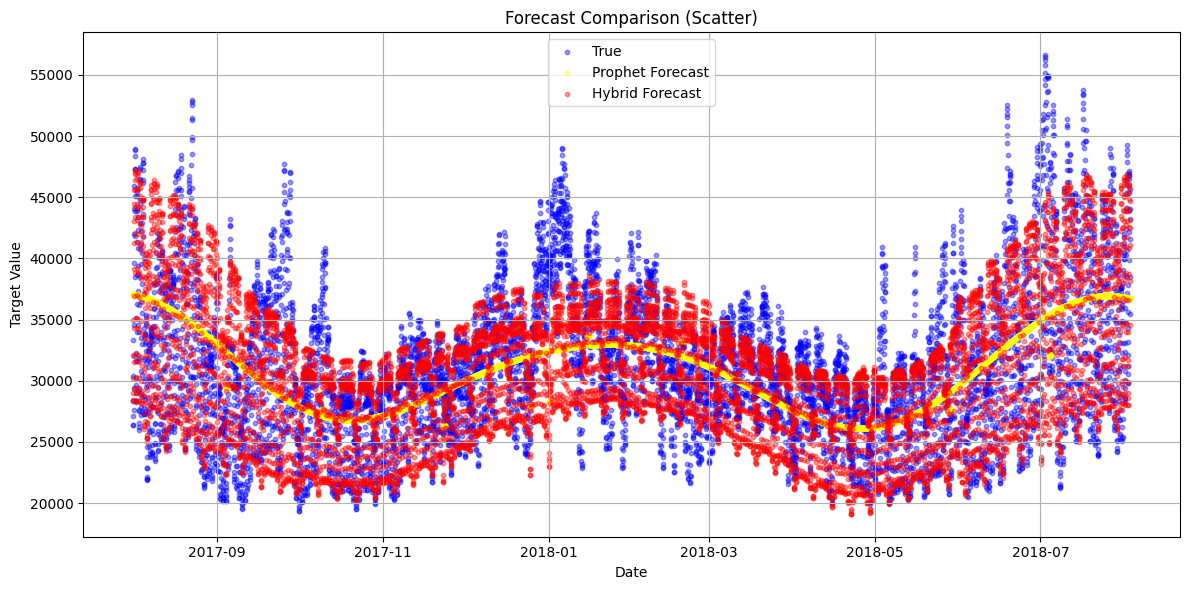

In [24]:
plt.figure(figsize=(12, 6))
plt.scatter(test_set['ds'], test_set['y'], label='True', color='blue', s=10, alpha=0.4)
plt.scatter(test_set['ds'], forecast_test['yhat'], label='Prophet Forecast', color='yellow', s=10, alpha=0.4)
plt.scatter(test_set['ds'][:len(hybrid_forecast_test)], hybrid_forecast_test, label='Hybrid Forecast', color='red', s=10, alpha=0.4)
plt.legend()
plt.title("Forecast Comparison (Scatter)")
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:**
- The Prophet forecast (yellow) follows the overall seasonal trend but often misses local fluctuations and spikes.
- The Hybrid forecast (red) more closely tracks the true values (blue), especially during periods of rapid change or local anomalies.
- This visual demonstrates the hybrid model’s improved ability to capture both global and local patterns, reducing forecast error compared to Prophet alone.

> **Conclusion:**  
> The hybrid approach yields forecasts that are both smoother and more accurate, especially in capturing the true variability of the load data.

---

#### 🔍 Zoomed-In Forecast Comparison: True vs. Prophet vs. Hybrid

The scatter plot below provides a close-up view of the PJME hourly load forecasts for the period **2018-01-05 to 2018-01-10**. It compares:

- **True values** (black): Actual observed load.
- **Prophet Forecast** (blue): Standalone Prophet model predictions, which capture the overall trend but may miss local variations.
- **Hybrid Forecast** (green): Hybrid Prophet + XGBoost predictions, which add machine learning-based corrections to Prophet's output.


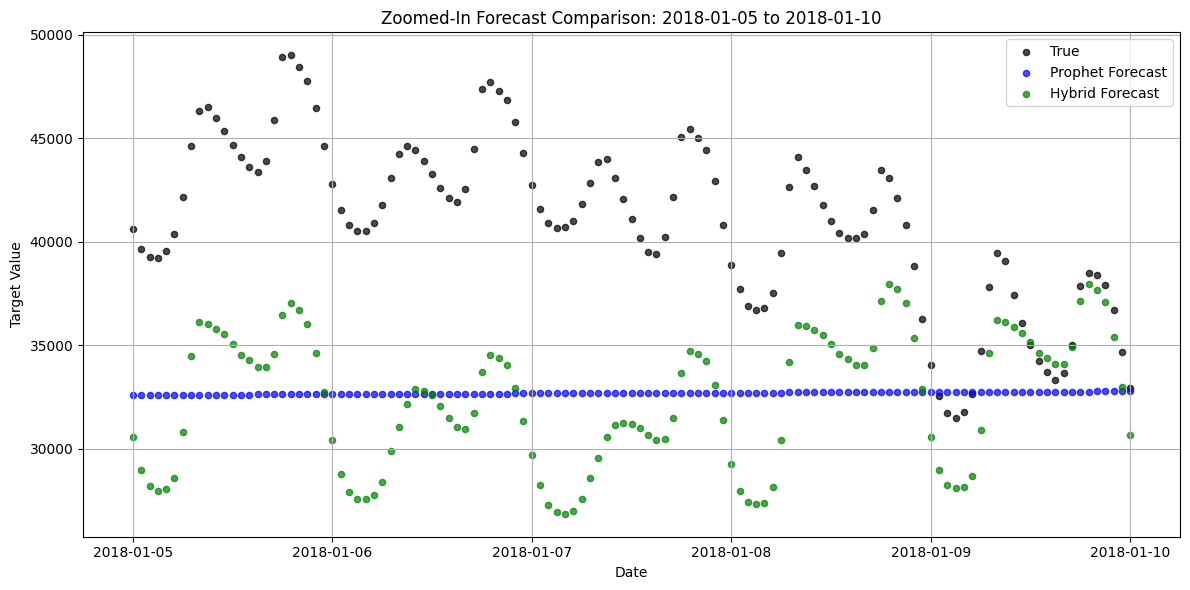

In [30]:
# Create safe copies
test_set_copy = test_set.copy()
forecast_test_copy = forecast_test.copy()

# Reset indices on the copies to ensure alignment
test_set_copy.reset_index(drop=True, inplace=True)
forecast_test_copy.reset_index(drop=True, inplace=True)

# Set zoom-in range
zoom_start = '2018-01-05'
zoom_end = '2018-01-10'

# Create mask based on date range
mask = (test_set_copy['ds'] >= zoom_start) & (test_set_copy['ds'] <= zoom_end)

# Apply mask
ds_zoom = test_set_copy['ds'][mask]
y_true_zoom = test_set_copy['y'][mask]
prophet_zoom = forecast_test_copy['yhat'][mask]

# Create hybrid forecast series aligned with test_set['ds']
hybrid_series = pd.Series(hybrid_forecast_test, index=test_set_copy.index)
hybrid_zoom = hybrid_series[mask]

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(ds_zoom, y_true_zoom, label='True', color='black', s=20, alpha=0.7)
plt.scatter(ds_zoom, prophet_zoom, label='Prophet Forecast', color='blue', s=20, alpha=0.7)
plt.scatter(ds_zoom, hybrid_zoom, label='Hybrid Forecast', color='green', s=20, alpha=0.7)

plt.legend()
plt.title(f"Zoomed-In Forecast Comparison: {zoom_start} to {zoom_end}")
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.grid(True)
plt.tight_layout()
plt.show()



**Interpretation:**
- The Prophet forecast (blue) is relatively flat, showing limited ability to capture short-term fluctuations.
- The Hybrid forecast (green) more closely follows the true load (black), especially during rapid changes and local peaks/troughs.
- Notably, the hybrid model is able to capture the overall shape and structure of the true signal, including the timing and magnitude of local peaks and valleys, which Prophet alone misses.
- This zoomed-in view highlights the hybrid model’s improved responsiveness to local dynamics, demonstrating its advantage over Prophet alone for high-frequency, real-world forecasting.

> **Conclusion:**  
> The hybrid approach significantly enhances short-term accuracy, making it more suitable for operational forecasting where local deviations and the true shape shape of the signal matter.